# Signal Sampling, Quantization, and Reconstruction Analysis

### 🎯 Objective
To simulate the complete **Analog-to-Digital (ADC)** and **Digital-to-Analog (DAC)** conversion process and verify the **Nyquist Sampling Theorem** using Python.

### 🧠 Description
This notebook demonstrates the fundamental concepts of Digital Signal Processing (DSP) by:

* **Generating an Analog Signal:** Creating a composite signal from multiple sine waves.
* **Sampling:** Converting the continuous signal into a discrete time signal at various frequencies ($f_s$).
* **Quantization:** Mapping continuous amplitude values to discrete levels (8-bit) and calculating **Quantization Error**.
* **Reconstruction:** Converting the digital signal back to analog form.
* **Visualization:** Plotting the Analog, Discrete, Digital, and Reconstructed signals side-by-side to analyze distortion and aliasing.

This experiment helps in understanding how sampling rates impact signal integrity and the importance of satisfying the Nyquist criteria ($f_s \geq 2f_{max}$).

fs = 350 Hz -> Samples = 7, Required Memory = 56 bits
fs = 750 Hz -> Samples = 15, Required Memory = 120 bits
fs = 2500 Hz -> Samples = 50, Required Memory = 400 bits


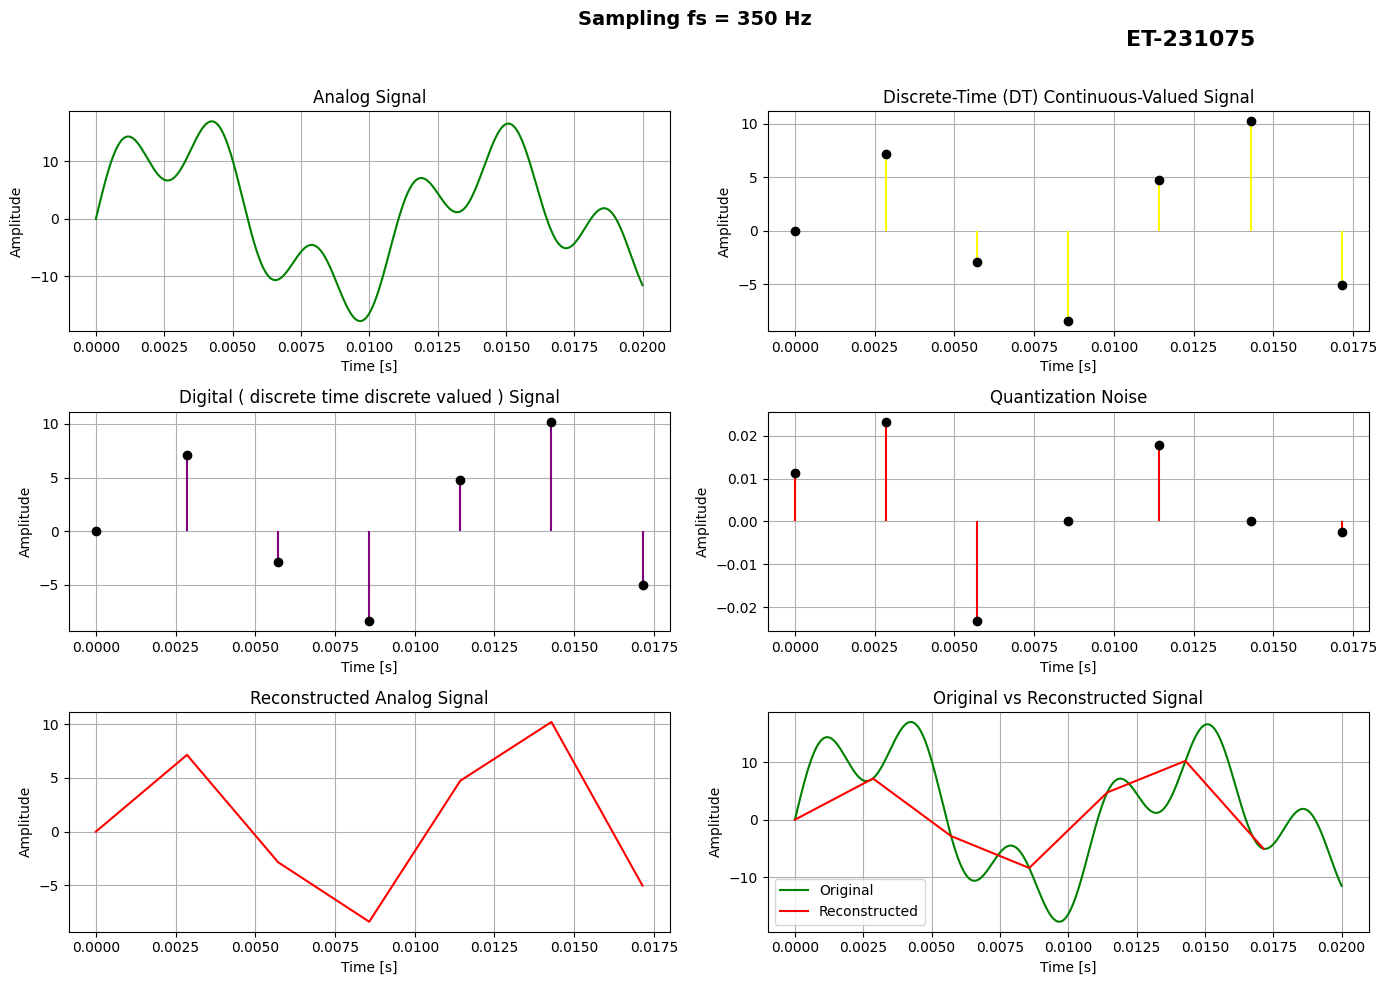

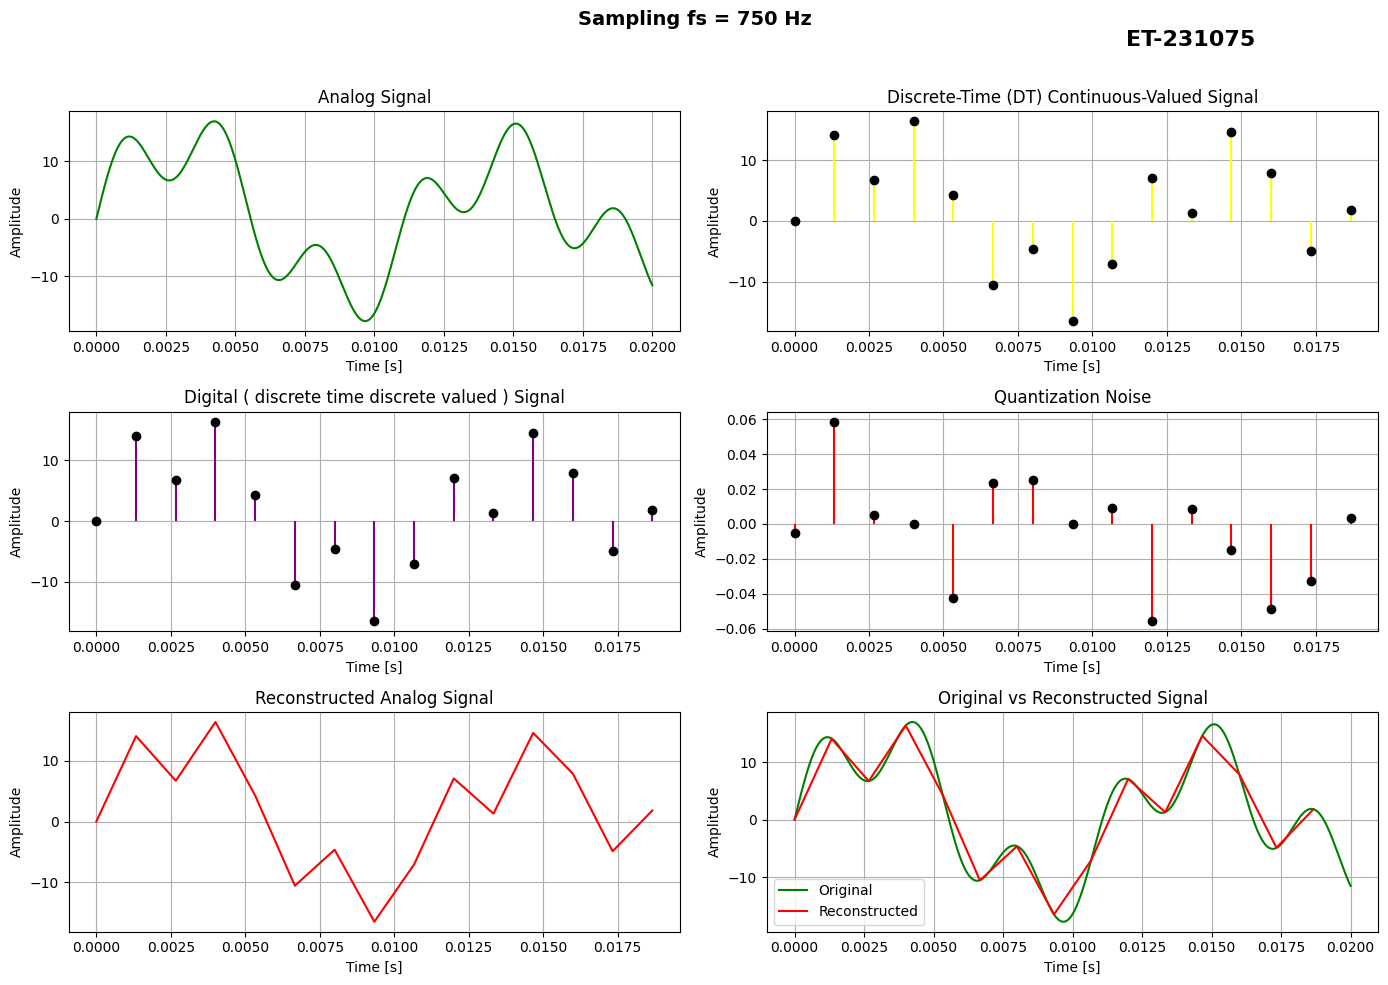

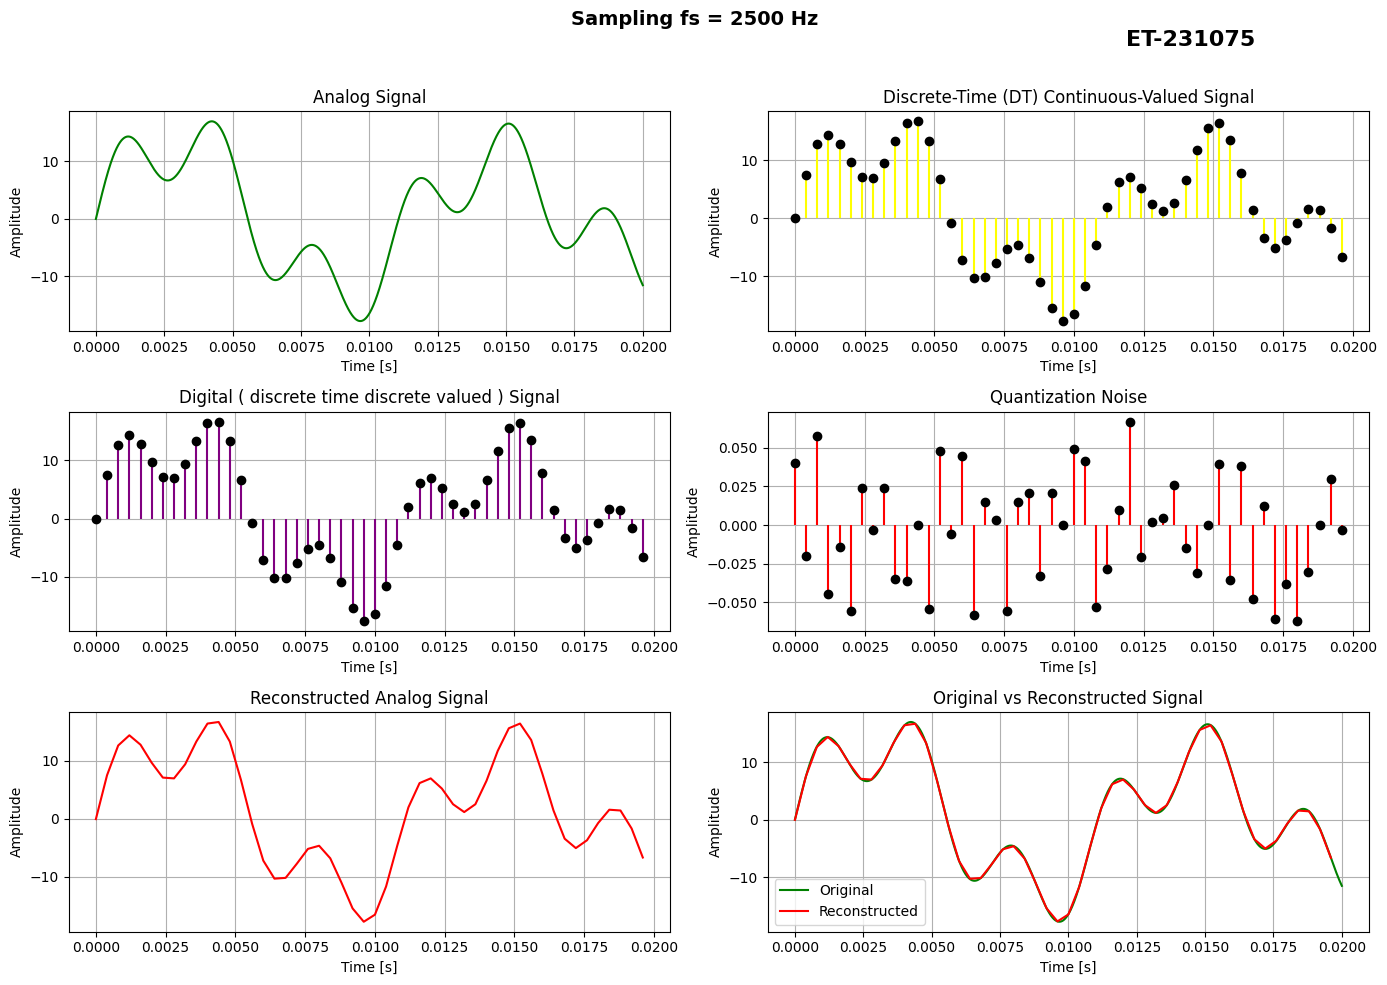

In [1]:
import numpy as np
import matplotlib.pyplot as plt

A = 2
L = 3
B = 1
C = 0
M = 7
N = 5
# f1 = 150/2 =75 Hz
# f2 = 182/2 =91 Hz
# f3 = 560/2 =280 Hz
# f4 = 144/2 =72 Hz
# The maximum frequency is  280 Hz
# The Nyquist Rate is defined as fs= 2*fmax = 560 Hz
# so, we can take 3 values like 350Hz,750Hz & 5000Hz

StopTime = 0.02
bits = 8
fs_list = [350, 750, 2500]

t_cont = np.linspace(0, StopTime, 200000)
xa = (L * np.sin(50 * np.pi * L * t_cont) + (A + M) * np.sin(26 * np.pi * M * t_cont) + (A + N) * np.sin(112 * np.pi * N * t_cont) + A * np.sin(72 * np.pi * A * t_cont))

for fs in fs_list:
    Ts = 1 / fs
    t = np.arange(0, StopTime, Ts)

    x = (L * np.sin(50 * np.pi * L * t) + (A + M) * np.sin(26 * np.pi * M * t) + (A + N) * np.sin(112 * np.pi * N * t) + A * np.sin(72 * np.pi * A * t))

    Lq = 2 ** bits 
    x_min = np.min(x)
    x_max = np.max(x)
    q_step = (x_max - x_min) / (Lq - 1)
    xq = np.round((x - x_min) / q_step) * q_step + x_min
    error = x - xq

    t_rec = t
    x_rec = xq

    plt.figure(figsize=(14, 10))
    plt.suptitle(f"Sampling fs = {fs} Hz", fontsize=14, fontweight='bold')
    plt.figtext(0.90, 0.96, "ET-231075", ha="right", va="top", fontsize=16, color="k",fontweight='bold')
    plt.subplot(3, 2, 1)
    plt.plot(t_cont, xa, 'g')
    plt.title('Analog Signal')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.grid(True)

    plt.subplot(3, 2, 2)
    plt.stem(t, x, basefmt=" ",linefmt='yellow',markerfmt='ko')
    plt.title('Discrete-Time (DT) Continuous-Valued Signal')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.grid(True)

    plt.subplot(3, 2, 3)
    plt.stem(t, xq, basefmt=" ",linefmt='purple',markerfmt='ko')
    plt.title('Digital ( discrete time discrete valued ) Signal')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.grid(True)

    plt.subplot(3, 2, 4)
    plt.stem(t, error, basefmt=" ",linefmt='red',markerfmt='ko')
    plt.title('Quantization Noise')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.grid(True)

    plt.subplot(3, 2, 5)
    plt.plot(t_rec, x_rec, 'r')
    plt.title('Reconstructed Analog Signal')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.grid(True)

    plt.subplot(3, 2, 6)
    plt.plot(t_cont, xa, 'g', label='Original')
    plt.plot(t_rec, x_rec, 'r', label='Reconstructed')
    plt.title('Original vs Reconstructed Signal')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    num_samples = len(t)
    memory_bits = num_samples * bits
    print(f"fs = {fs} Hz -> Samples = {num_samples}, Required Memory = {memory_bits} bits")

plt.show()